In [1]:
# limit the thread used by numpy 
import os
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"
os.environ["VECLIB_MAXIMUM_THREADS"] = "1"  

import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
# import matplotlib
# matplotlib.rcParams['text.usetex'] = True
# matplotlib.rcParams['font.family'] = 'serif'

from Triangle.Constants import *
from Triangle.Orbit import * 
from Triangle.Noise import *
from Triangle.FFTTools import *
from Triangle.TDI import *
from Triangle.Data import * 

from Triangle_BBH.Waveform import * 
from Triangle_BBH.Response import *
from Triangle_BBH.Utils import Likelihood, Fstatistics
from Triangle_BBH.Fisher import *

# import multiprocessing
# if __name__=='__main__':
#     multiprocessing.set_start_method("fork")
    
import bilby 

# np.random.seed(114517)
# xp.random.seed(114514)

PyCBC.libutils: pkg-config call failed, setting NO_PKGCONFIG=1


has cupy
has cupy
has BBHx waveform


In [64]:
class WaveformGeneratorFRef(WaveformGenerator):
    def __init__(self, mode='full'):
        super().__init__(mode)
    
    def __call__(self, parameters, Nfreqs=1024, fmin=1e-5, fmax=1e-1, fref=1e-3, freqs=None):
        Nevents = np.atleast_1d(parameters["chirp_mass"]).shape[0]
        
        # conversion of parameters
        parameters_in = {}
        parameters_in["Mc"] = np.atleast_1d(parameters["chirp_mass"])
        parameters_in["eta"] = np.atleast_1d(eta_q(parameters["mass_ratio"]))
        parameters_in["chi1z"] = np.atleast_1d(parameters["spin_1z"])
        parameters_in["chi2z"] = np.atleast_1d(parameters["spin_2z"])
        parameters_in["dL"] = np.atleast_1d(parameters["luminosity_distance"] / 1e3) 
        parameters_in['reference_time'] = np.atleast_1d(parameters['reference_time'])
        
        # calculate frequency grids of shape (Nfreqs, Nevents) (will be transposed later), independent of modes
        if type(freqs) == np.ndarray:
            if freqs.shape[0] == Nevents:
                fgrids = np.transpose(freqs) # (Nfreqs, Nevents)
            else: 
                fgrids = np.transpose(np.tile(freqs, (Nevents, 1))) # (Nevents, Nfreqs) -> (Nfreqs, Nevents)
        else:
            fminarr = np.full(Nevents, fmin)
            fmaxarr = np.full(Nevents, fmax)
            fgrids = np.geomspace(fminarr, fmaxarr, num=int(Nfreqs)) # (Nfreqs, Nevents)
        
        FSTEP = 1e-6 # TEST
        # if fref is None:   
        #     self.fcutarr = self.waveform.fcut(**parameters_in) # (Nevents) TEST  
        #     self.fcutarr = self.fcutarr - 1e-4 # TEST 
        # else: 
        self.fcutarr = np.ones(Nevents) * fref
        fgrids_cut = np.array([
            self.fcutarr - FSTEP, 
            self.fcutarr
        ]) # (2, Nevents) TEST 

        fgrids = np.concatenate((fgrids, fgrids_cut), axis=0) # (Nfreqs + 2, Nevents)
        
        # calculate amplitudes, phases by modes, each mode is originally a (Nfreqs+2, Nevents) array (will be transposed)
        amplitudes = self.waveform.Ampl(fgrids, **parameters_in) # dict
        phases = self.waveform.Phi(fgrids, **parameters_in) # dict
        
        # adjust keys to [(2,2), (2, 1), (3, 2), (3, 3), (4, 3), (4, 4)] and shapes to (Nevents, Nfreqs)
        amps_out = {}
        phas_out = {}
        for k, v in amplitudes.items():
            amps_out[(int(k[0]), int(k[1]))] = (v.T)[:, :-2] # (Nevents, Nfreqs)
            phas_out[(int(k[0]), int(k[1]))] = phases[k].T # (Nevents, Nfreqs+2)
        fgrids = fgrids.T # (Nevents, Nfreqs+2)
        
        dphase_22_cut = (phas_out[(2,2)][:, -1] - phas_out[(2,2)][:, -2]) / FSTEP # phase derivative (Nevents) TEST 
        phase_mode_correction1 = (-dphase_22_cut + TWOPI * parameters_in['reference_time'] * DAY)[:, np.newaxis] * (fgrids - self.fcutarr[:, np.newaxis]) # (Nevents, Nfreqs+2) TEST
        phase_22_cut = phas_out[(2,2)][:, -1] # (Nevents)
        for k, v in phas_out.items(): 
            phase_mode_correction2 = -0.5 * k[1] * phase_22_cut # -m/2 * phi_cut_22 (Nevents) TEST 
            phas_out[k] = (v + phase_mode_correction1 + phase_mode_correction2[:, np.newaxis])[:, :-2] # (Nevents, Nfreqs)
        
        fgrids = fgrids[:, :-2] # (Nevents, Nfreqs)
        # calculate time grids by t-f relationship 
        tfs_out = {}
        dfgrids = np.gradient(fgrids, axis=1) # (Nevents, Nfreqs) TEST 
        for k, v in phas_out.items(): 
            dphase = np.gradient(v, axis=1) # (Nevents, Nfreqs) TEST 
            tfs_out[k] = dphase / dfgrids / TWOPI # (Nevents, Nfreqs) TEST 
 
        return fgrids, amps_out, phas_out, tfs_out # each item of shape (Nevents, Nfreqs)

In [65]:
class FDTDIResponseGeneratorFRef(FDTDIResponseGenerator):
    """   
        parametrization: 
            chirp_mass
            mass_ratio 
            spin_1z
            spin_2z
            reference_time 
            reference_phase 
            luminosity_distance 
            inclination 
            longitude 
            latitude 
            psi 
    """
    def __init__(self, orbit_class, waveform_generator):
        """ the waveform generator used here should depend on fref """
        super().__init__(orbit_class, waveform_generator)
    
    def Response(
        self, 
        parameters, 
        freqs, 
        fmin=1e-5, # used to calculate freq grid
        fmax=1e-1, # used to calculate freq grid
        fref=1e-3, # used to set reference point 
        Nfreqs=1024, # used to calculate freq grid
        modes=[(2, 2), (3, 3), (4, 4), (2, 1), (3, 2), (4, 3)], 
        tmin=None, # minimum time of orbit in day 
        tmax=None, # maximum time of orbit in day
        tref_at_constellation=False, # whether tc is the coalescence time at constellation center (True) or SSB (False)
        TDIGeneration='2nd',
        optimal_combination=True,
        interpolation_method='cubic',
        output_by_mode=False, 
        ):
        
        # convert scalar parameters to arraies 
        parameter_dict = dict() 
        for k, v in parameters.items():
            parameter_dict[k] = np.atleast_1d(v)
        Nevents = parameter_dict['chirp_mass'].shape[0]
        
        # these 2 parameters are duplicated since the Plm function needs "coalescence_phase" and the time frame conversion needs "coalescence_time"
        # they should still be interpreted as reference values rather than values at merger 
        parameter_dict["coalescence_time"] = parameter_dict["reference_time"]
        parameter_dict["coalescence_phase"] = parameter_dict["reference_phase"]
                
        # calculate polarization tensors (mode-dependent) and wavevectors (mode-independent)
        Plm = self.PolarBasis_lm(parameters=parameter_dict, modes=modes) 
        k = self.WaveVector(parameters=parameter_dict) 

        parameter_dict.pop('coalescence_phase') # REMOVE useless parameter 
        
        # convert the reference time from constellaton center to SSB
        if tref_at_constellation:
            tref_delay = self.SSBToConstellationDelay(k, parameter_dict) # (Nevent)
            # parameter_dict['coalescence_time'] += -tref_delay / DAY # (Nevent)
            parameter_dict['reference_time'] += -tref_delay / DAY # (Nevent)

        parameter_dict.pop('coalescence_time') # REMOVE useless parameter 
        
        # calculate frequency grids (mode-independent), waveforms and time grids (mode-dependent)
        if interpolation_method == None:
            fgrids, amps, phas, tgrids = self.waveform(parameters=parameter_dict, Nfreqs=Nfreqs, fmin=fmin, fmax=fmax, fref=fref, freqs=np.tile(freqs, (Nevents, 1)))
        else:
            fgrids, amps, phas, tgrids = self.waveform(parameters=parameter_dict, Nfreqs=Nfreqs, fmin=fmin, fmax=fmax, fref=fref, freqs=None)

        # calculate transfer function at the frequency and time grids and then interpolate (Nevents, Nfreqs) --> (Nevents, Nfreqs_out)
        Nfreqs_out = freqs.shape[-1]
        fill_value=0.
        if output_by_mode:
            Nmode = len(modes)
            X = np.zeros((Nmode, Nevents, Nfreqs_out), dtype=np.complex128)
            Y = np.zeros((Nmode, Nevents, Nfreqs_out), dtype=np.complex128)
            Z = np.zeros((Nmode, Nevents, Nfreqs_out), dtype=np.complex128)
            if interpolation_method == None: 
                for imode, mode in enumerate(modes):
                    _, GTDI = self.TransferFunction(t=tgrids[mode], f=fgrids, k=k, Plm=Plm[mode], TDIGeneration=TDIGeneration, tmin=tmin, tmax=tmax)
                    Xamp_int = GTDI['X'] * amps[mode]
                    Yamp_int = GTDI['Y'] * amps[mode]
                    Zamp_int = GTDI['Z'] * amps[mode]
                    phase_int = phas[mode]
                    X[imode] = Xamp_int * np.exp(1.j * phase_int)
                    Y[imode] = Yamp_int * np.exp(1.j * phase_int)
                    Z[imode] = Zamp_int * np.exp(1.j * phase_int)       
            else:
                for imode, mode in enumerate(modes):
                    _, GTDI = self.TransferFunction(t=tgrids[mode], f=fgrids, k=k, Plm=Plm[mode], TDIGeneration=TDIGeneration, tmin=tmin, tmax=tmax)
                    Xamp_int = GTDI['X'] * amps[mode]
                    Yamp_int = GTDI['Y'] * amps[mode]
                    Zamp_int = GTDI['Z'] * amps[mode]
                    phase_int = phas[mode]
                    Xamp_func = interp1d(x=fgrids[0], y=Xamp_int, kind=interpolation_method, axis=1, bounds_error=False, fill_value=fill_value)
                    Yamp_func = interp1d(x=fgrids[0], y=Yamp_int, kind=interpolation_method, axis=1, bounds_error=False, fill_value=fill_value)
                    Zamp_func = interp1d(x=fgrids[0], y=Zamp_int, kind=interpolation_method, axis=1, bounds_error=False, fill_value=fill_value)
                    phase_func = interp1d(x=fgrids[0], y=phase_int, kind=interpolation_method, axis=1, bounds_error=False, fill_value=fill_value)
                    Xamp = Xamp_func(freqs)
                    Yamp = Yamp_func(freqs)
                    Zamp = Zamp_func(freqs)
                    phase = phase_func(freqs)
                    X[imode] = Xamp * np.exp(1.j * phase)
                    Y[imode] = Yamp * np.exp(1.j * phase)
                    Z[imode] = Zamp * np.exp(1.j * phase)       
        else:
            X = np.zeros((Nevents, Nfreqs_out), dtype=np.complex128)
            Y = np.zeros((Nevents, Nfreqs_out), dtype=np.complex128)
            Z = np.zeros((Nevents, Nfreqs_out), dtype=np.complex128)
            if interpolation_method == None: 
                for mode in modes:
                    _, GTDI = self.TransferFunction(t=tgrids[mode], f=fgrids, k=k, Plm=Plm[mode], TDIGeneration=TDIGeneration, tmin=tmin, tmax=tmax)
                    Xamp_int = GTDI['X'] * amps[mode]
                    Yamp_int = GTDI['Y'] * amps[mode]
                    Zamp_int = GTDI['Z'] * amps[mode]
                    phase_int = phas[mode]
                    X += Xamp_int * np.exp(1.j * phase_int)
                    Y += Yamp_int * np.exp(1.j * phase_int)
                    Z += Zamp_int * np.exp(1.j * phase_int)
            else:
                for mode in modes:
                    _, GTDI = self.TransferFunction(t=tgrids[mode], f=fgrids, k=k, Plm=Plm[mode], TDIGeneration=TDIGeneration, tmin=tmin, tmax=tmax)
                    Xamp_int = GTDI['X'] * amps[mode]
                    Yamp_int = GTDI['Y'] * amps[mode]
                    Zamp_int = GTDI['Z'] * amps[mode]
                    phase_int = phas[mode]
                    Xamp_func = interp1d(x=fgrids[0], y=Xamp_int, kind=interpolation_method, axis=1, bounds_error=False, fill_value=fill_value)
                    Yamp_func = interp1d(x=fgrids[0], y=Yamp_int, kind=interpolation_method, axis=1, bounds_error=False, fill_value=fill_value)
                    Zamp_func = interp1d(x=fgrids[0], y=Zamp_int, kind=interpolation_method, axis=1, bounds_error=False, fill_value=fill_value)
                    phase_func = interp1d(x=fgrids[0], y=phase_int, kind=interpolation_method, axis=1, bounds_error=False, fill_value=fill_value)
                    Xamp = Xamp_func(freqs)
                    Yamp = Yamp_func(freqs)
                    Zamp = Zamp_func(freqs)
                    phase = phase_func(freqs)
                    X += Xamp * np.exp(1.j * phase)
                    Y += Yamp * np.exp(1.j * phase)
                    Z += Zamp * np.exp(1.j * phase)
        if Nevents == 1: 
            X = np.conjugate(X[0])
            Y = np.conjugate(Y[0])
            Z = np.conjugate(Z[0])
        else:
            X = np.conjugate(X)
            Y = np.conjugate(Y)
            Z = np.conjugate(Z)
        
        if optimal_combination:
            A, E, T = self.AETfromXYZ(X, Y, Z)
            results = np.array([A, E, T]) 
        else:
            results = np.array([X, Y, Z])
        
        results[np.abs(results)<1e-25]=0.
        return results 


In [2]:
t_start = 0. * DAY # start time in s
Tobs = 90. * DAY # data length in s 
t_end = t_start + Tobs # end time in s 
dt = 10. # time cadance in s 
fsample = 1. / dt # sampling rate in Hz 
data_frequencies_full = np.fft.rfftfreq(n=int(Tobs/dt), d=dt) # frequecies where waveform will be calculated 
delta_f = 1. / Tobs

# mask the "null" frequencies, which may cause singularity in the calculation of likelihood 
mask = np.ones_like(data_frequencies_full, dtype=bool)
for i in range(1, 50): 
    mask_idx = np.where(np.abs(data_frequencies_full - i*0.025)<i*3e-4)[0]
    mask[mask_idx] = False 

# remove the frequencies below Taiji sensitive band 
mask_idx = np.where(data_frequencies_full < 1e-5)[0]
mask[mask_idx] = False 

data_frequencies = data_frequencies_full[mask]

data_frequencies.shape, data_frequencies_full.shape 

((379392,), (388801,))

In [3]:
PSDfunc = TDIPSDs()
data_psd = PSDfunc.PSD_A2(data_frequencies)

In [4]:
# the path of Taiji orbit 
orbit = Orbit(
    OrbitDir="../../Triangle-Simulator/OrbitData/MicroSateOrbitEclipticTCB", 
    ) 

# initialize  waveform generator 
WFG1 = WaveformGenerator(
    mode="primary", 
    # mode="full", 
)
WFG2 = WaveformGeneratorFRef(
    mode="primary", 
    # mode="full", 
)

# initialize response generator 
FDTDI1 = FDTDIResponseGenerator(
    orbit_class=orbit, 
    waveform_generator=WFG1, 
)
FDTDI2 = FDTDIResponseGeneratorFRef(
    orbit_class=orbit, 
    waveform_generator=WFG2, 
)

# response settings 
response_kwargs_interp1 = dict(
    fmin=1e-5, # used to calculate freq grid
    fmax=1e-1, # used to calculate freq grid
    Nfreqs=1024, # used to calculate freq grid
    modes=[(2, 2)], 
    tmin=t_start / DAY, # start time in day 
    tmax=t_end / DAY, # end time in day  
    tc_at_constellation=True, # whether tc is the coalescence time at constellation center (True) or SSB (False)
    TDIGeneration='2nd',
    optimal_combination=True, # True for AET, False for XYZ 
    output_by_mode=False, 
    interpolation_method='cubic',
)

# response settings 
response_kwargs_interp2 = response_kwargs_interp1.copy()
response_kwargs_interp2.pop("tc_at_constellation")
response_kwargs_interp2["tref_at_constellation"] = response_kwargs_interp1["tc_at_constellation"]


In [5]:
lgMc_prior = [5.5, 6.5]
q_prior = [0.1, 1]
s1_prior = [-0.9, 0.9]
s2_prior = [-0.9, 0.9]
tc_prior = [(t_start + 0.3 * Tobs) / DAY, (t_end - 0.3 * Tobs) / DAY] # ensure the inclusion of long enough GW waveform 
lam_prior = [0, TWOPI]
sinbeta_prior = [-1., 1.]
intrinsic_param_priors = np.array([
    lgMc_prior, 
    q_prior, 
    s1_prior, 
    s2_prior, 
    tc_prior, 
    lam_prior, 
    sinbeta_prior, 
])

lgdl_prior = [4., 5.]

# generate source parameter and clean signal 
mbhb_parameters1 = {
    'chirp_mass': np.power(10., np.random.uniform(lgMc_prior[0], lgMc_prior[1])), 
    'mass_ratio': np.random.uniform(q_prior[0], q_prior[1]), 
    'spin_1z': np.random.uniform(s1_prior[0], s1_prior[1]),
    'spin_2z': np.random.uniform(s2_prior[0], s2_prior[1]),
    'coalescence_time': np.random.uniform(tc_prior[0], tc_prior[1]), 
    'coalescence_phase': np.random.uniform(0, TWOPI),
    'luminosity_distance': np.power(10., np.random.uniform(lgdl_prior[0], lgdl_prior[1])), 
    'inclination': np.arccos(np.random.uniform(-1., 1.)), # [rad]
    'longitude': np.random.uniform(lam_prior[0], lam_prior[1]), # [rad]
    'latitude': np.arcsin(np.random.uniform(sinbeta_prior[0], sinbeta_prior[1])), # [rad]
    'psi': np.random.uniform(0, PI) # [rad]
    }

mbhb_parameters2 = mbhb_parameters1.copy() 
mbhb_parameters2.pop("coalescence_time")
mbhb_parameters2.pop("coalescence_phase")
mbhb_parameters2["reference_time"] = mbhb_parameters1["coalescence_time"]
mbhb_parameters2["reference_phase"] = mbhb_parameters1["coalescence_phase"]

mbhb_parameters1, mbhb_parameters2

({'chirp_mass': 494067.91779219126,
  'mass_ratio': 0.7691566670140093,
  'spin_1z': 0.15222719436831122,
  'spin_2z': 0.6009448264676293,
  'coalescence_time': 33.14588926736135,
  'coalescence_phase': 4.558511702264443,
  'luminosity_distance': 16390.40677471328,
  'inclination': 1.940082634934586,
  'longitude': 3.5598201037096593,
  'latitude': 1.397100551990431,
  'psi': 0.05328608926334558},
 {'chirp_mass': 494067.91779219126,
  'mass_ratio': 0.7691566670140093,
  'spin_1z': 0.15222719436831122,
  'spin_2z': 0.6009448264676293,
  'luminosity_distance': 16390.40677471328,
  'inclination': 1.940082634934586,
  'longitude': 3.5598201037096593,
  'latitude': 1.397100551990431,
  'psi': 0.05328608926334558,
  'reference_time': 33.14588926736135,
  'reference_phase': 4.558511702264443})

In [6]:
wf_channels1 = FDTDI1.Response(
    mbhb_parameters1, 
    data_frequencies, 
    **response_kwargs_interp1, 
)

response_kwargs_interp2["fref"] = WFG1.f_ref[0]
wf_channels2 = FDTDI2.Response(
    mbhb_parameters2, 
    data_frequencies, 
    **response_kwargs_interp2, 
)

WFG1.f_ref[0], WFG2.fcutarr

(0.015580280433951703, array([0.01558028]))

In [7]:
print("SNR (interpolated)", np.sqrt(4. / Tobs * np.sum(np.abs(wf_channels1[:2])**2 / data_psd)))
print("SNR (direct)", np.sqrt(4. / Tobs * np.sum(np.abs(wf_channels2[:2])**2 / data_psd)))
print("SNR (residual)", np.sqrt(4. / Tobs * np.sum(np.abs(wf_channels1[:2] - wf_channels2[:2])**2 / data_psd)))

SNR (interpolated) 1927.3488394260116
SNR (direct) 1927.3498813239128
SNR (residual) 1.3592546235297776


(5e-05, 0.1)

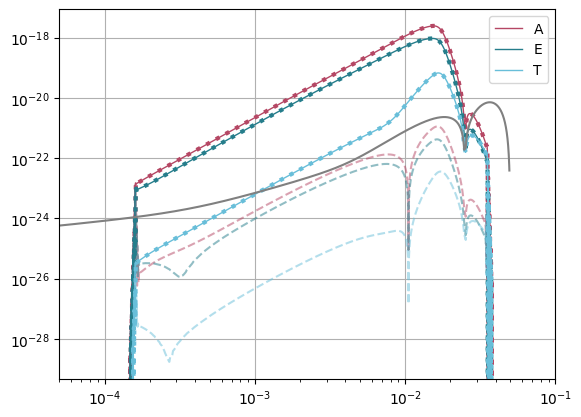

In [8]:
ch_names = ["A", "E", "T"]
ch_colors = [RED, GREEN1, BLUE]
psdfunc = TDIPSDs()
for i in range(3):
    plt.loglog(data_frequencies, np.abs(wf_channels1[i]) * 2. * data_frequencies, color=ch_colors[i], label=ch_names[i], linestyle="-", linewidth=1)
    plt.loglog(data_frequencies, np.abs(wf_channels2[i]) * 2. * data_frequencies, color=ch_colors[i], linestyle=":", linewidth=3)
    plt.loglog(data_frequencies, np.abs(wf_channels1[i] - wf_channels2[i]) * 2. * data_frequencies, color=ch_colors[i], linestyle="--", alpha=0.5)
plt.loglog(data_frequencies, np.sqrt(psdfunc.PSD_X2(data_frequencies) * data_frequencies), color="grey")
plt.legend()
plt.grid()
# plt.ylim(1e-25,)
plt.xlim(5e-5, 0.1)

In [9]:
f1, amp1, pha1, tf1 = WFG1(
    parameters=mbhb_parameters1, 
    Nfreqs=1024, 
    fmin=1e-5, 
    fmax=0.1, 
)

f2, amp2, pha2, tf2 = WFG2(
    parameters=mbhb_parameters2, 
    Nfreqs=1024, 
    fmin=1e-5, 
    fmax=0.1, 
    fref=WFG1.f_ref[0]
)

WFG1.f_ref[0]

0.015580280433951703

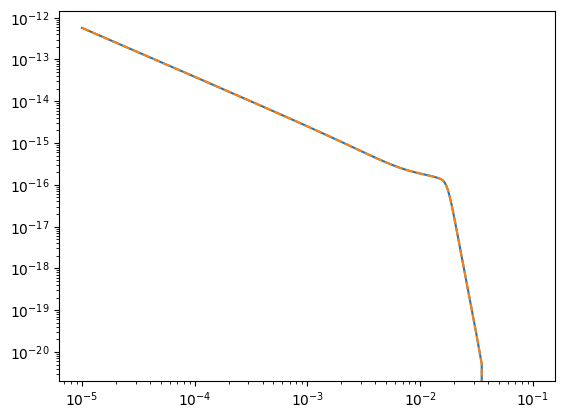

In [10]:
plt.loglog(f1[0], amp1[(2,2)][0])
plt.loglog(f2[0], amp2[(2,2)][0], linestyle="--")

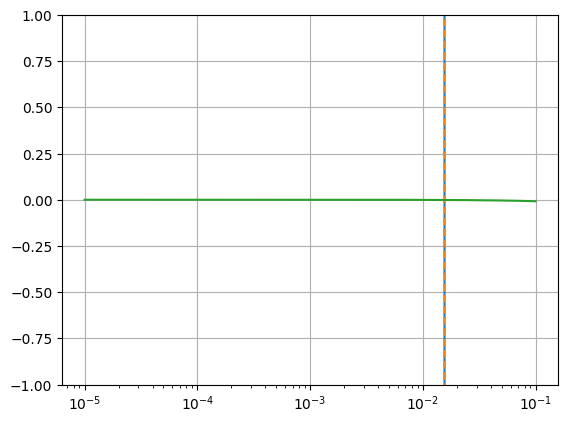

In [11]:
plt.semilogx(f1[0], pha1[(2,2)][0])
plt.semilogx(f2[0], pha2[(2,2)][0], linestyle="--")
plt.semilogx(f1[0], pha1[(2,2)][0]-pha2[(2,2)][0])
plt.ylim(-1, 1)
plt.grid()

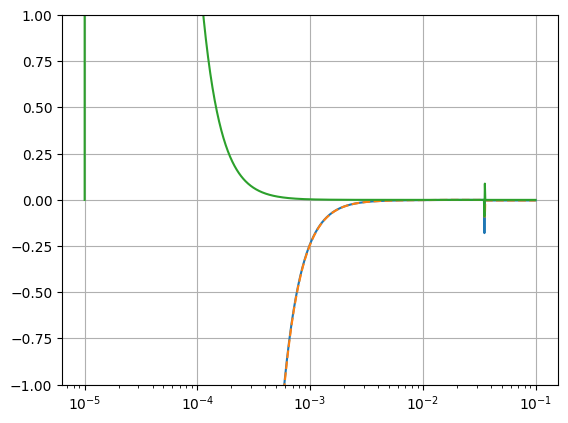

In [12]:
plt.semilogx(f1[0], tf1[(2,2)][0] / DAY - mbhb_parameters1["coalescence_time"])
plt.semilogx(f2[0], tf2[(2,2)][0] / DAY - mbhb_parameters1["coalescence_time"], linestyle="--")
plt.semilogx(f1[0], tf1[(2,2)][0] / DAY - tf2[(2,2)][0] / DAY)
plt.ylim(-1, 1)
plt.grid()